# Real Training Debug: CLEVR Set Prediction

Translates the toy gradient analysis into the real training task. Goals:

1. **Set up a lightweight training loop** on real CLEVR data (no WandB, no Lightning, just raw PyTorch)
2. **Monitor per-epoch:**
   - `val_matched_dist` — Hungarian match quality
   - `pred_diversity` — mean pairwise distance between the N output predictions
   - `softmax_entropy` — mean entropy of softmax(-D/τ) weights (1.0 = fully uniform = blind loss)
   - `grad_diversity` — std/mean of per-slot gradient norms (0 = all slots get same signal)
3. **Visualise predictions** projected to 2D via PCA at each epoch snapshot
4. **Compare:** Chamfer vs Power-SM3 at τ ∈ {0.05, 0.1, 0.5}

In [12]:
import sys, json, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment
from torch.utils.data import DataLoader, Dataset

sys.path.insert(0, '..')
from influencerformer.losses import ChamferLoss, HungarianLoss, PowerSoftMinLoss
from influencerformer.networks import (
    SetTransformerEncoder, MLPSetDecoder, SetAutoencoder, DSPNModel,
)

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 1. Data

In [13]:
MATERIALS = ['rubber', 'metal']
COLORS    = ['gray', 'red', 'blue', 'green', 'brown', 'purple', 'cyan', 'yellow']
SHAPES    = ['sphere', 'cube', 'cylinder']
SIZES     = ['large', 'small']
OBJ_DIM   = 3 + len(MATERIALS) + len(COLORS) + len(SHAPES) + len(SIZES)  # 18
MAX_OBJECTS = 10


def encode_object(obj):
    """Encode CLEVR object dict → 18D float vector."""
    x, y, z = obj['3d_coords']
    vec = [x / 3.0, y / 3.0, z / 3.0]
    for cats, key in [(MATERIALS, 'material'), (COLORS, 'color'),
                      (SHAPES, 'shape'), (SIZES, 'size')]:
        oh = [0.0] * len(cats)
        if obj.get(key) in cats:
            oh[cats.index(obj[key])] = 1.0
        vec.extend(oh)
    return vec


class CLEVRSetDataset(Dataset):
    """CLEVR set dataset. Returns (noisy_state, clean_state, mask)."""

    def __init__(self, path, max_samples=None):
        with open(path) as f:
            scenes = json.load(f)['scenes']
        if max_samples:
            scenes = scenes[:max_samples]
        self.states, self.masks = [], []
        for scene in scenes:
            objects = scene['objects'][:MAX_OBJECTS]
            state = torch.zeros(MAX_OBJECTS, OBJ_DIM)
            mask  = torch.zeros(MAX_OBJECTS)
            for i, obj in enumerate(objects):
                state[i] = torch.tensor(encode_object(obj))
                mask[i]  = 1.0
            self.states.append(state)
            self.masks.append(mask)

    def __len__(self):  return len(self.states)
    def __getitem__(self, idx):
        state = self.states[idx]
        mask  = self.masks[idx]
        noise = 0.05 * torch.randn_like(state) * mask.unsqueeze(1)
        return state + noise, state, mask


TRAIN_PATH = '../data/clevr/scenes/CLEVR_train_scenes.json'
VAL_PATH   = '../data/clevr/scenes/CLEVR_val_scenes.json'

train_ds = CLEVRSetDataset(TRAIN_PATH, max_samples=5000)
val_ds   = CLEVRSetDataset(VAL_PATH,   max_samples=1000)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=4)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=4)

print(f'Train: {len(train_ds)} scenes, Val: {len(val_ds)} scenes')
print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

# Peek at distances in the data
inp, tgt, msk = next(iter(val_loader))
D_sample = torch.cdist(tgt, tgt)  # (B, N, N)
mask2d = msk.unsqueeze(2) * msk.unsqueeze(1)  # real-real pairs
off_diag = D_sample * mask2d * (1 - torch.eye(MAX_OBJECTS).unsqueeze(0))
real_dists = off_diag[off_diag > 0]
print(f'\nReal L2 distances between objects: mean={real_dists.mean():.3f}, '
      f'std={real_dists.std():.3f}, min={real_dists.min():.3f}')

Train: 5000 scenes, Val: 1000 scenes
Train batches: 79, Val batches: 16

Real L2 distances between objects: mean=2.568, std=0.451, min=0.640


## 2. Model + Monitoring Utilities

In [14]:
def make_model(d_model=128, latent_dim=128, hidden_dim=128):
    """Small MLP-decoder model for fast debug iterations."""
    encoder = SetTransformerEncoder(
        input_dim=OBJ_DIM, d_model=d_model, nhead=4,
        num_layers=2, latent_dim=latent_dim,
        dim_feedforward=d_model * 2, dropout=0.0,
    )
    decoder = MLPSetDecoder(
        latent_dim=latent_dim, hidden_dim=hidden_dim,
        max_objects=MAX_OBJECTS, obj_dim=OBJ_DIM,
    )
    return SetAutoencoder(encoder, decoder).to(DEVICE)


def make_dspn_model(d_model=128, latent_dim=128,
                    inner_lr=800.0, inner_steps=10):
    """DSPN model: same SetTransformer encoder + gradient-descent decoder."""
    encoder = SetTransformerEncoder(
        input_dim=OBJ_DIM, d_model=d_model, nhead=4,
        num_layers=2, latent_dim=latent_dim,
        dim_feedforward=d_model * 2, dropout=0.0,
    )
    return DSPNModel(
        encoder=encoder, obj_dim=OBJ_DIM, max_objects=MAX_OBJECTS,
        inner_lr=inner_lr, inner_steps=inner_steps,
    ).to(DEVICE)


@torch.no_grad()
def pred_diversity(preds, mask):
    """Mean pairwise L2 distance between predicted slots (real slots only).

    Low value → predictions are clustered (collapse).
    """
    B = preds.shape[0]
    divs = []
    for b in range(B):
        n = int(mask[b].sum().item())
        if n < 2: continue
        p = preds[b, :n]  # (n, D)
        D = torch.cdist(p.unsqueeze(0), p.unsqueeze(0))[0]  # (n, n)
        # off-diagonal mean
        off = D[~torch.eye(n, dtype=bool)]
        divs.append(off.mean().item())
    return float(np.mean(divs)) if divs else 0.0


@torch.no_grad()
def softmax_entropy(preds, targets, mask, tau):
    """Mean entropy of softmax(-D/tau, dim=preds) over targets.

    Normalised to [0, 1] where 1 = fully uniform (loss is blind).
    Only meaningful for softmin losses; included for all for comparison.
    """
    D = torch.cdist(preds, targets)  # (B, M, N)
    entropies = []
    for b in range(D.shape[0]):
        n = int(mask[b].sum().item())
        if n < 2: continue
        D_b = D[b, :n, :n]  # (n, n)
        w = torch.softmax(-D_b / tau, dim=0)  # (n, n): weights over preds per target
        H = -(w * torch.log(w + 1e-10)).sum(dim=0).mean()  # mean over targets
        H_max = np.log(n)
        entropies.append((H / H_max).item())
    return float(np.mean(entropies)) if entropies else 1.0


def grad_diversity(model, batch, loss_fn):
    """Ratio of grad_std / grad_mean across output slots after one forward+backward.

    Hooks the model output tensor (works for both MLP and DSPN architectures).
    High value → different slots get different signals.
    Low value → all slots receive the same gradient (centroid trap).
    """
    inp, tgt, msk = [x.to(DEVICE) for x in batch]

    slot_grads = {}
    def hook(grad):
        slot_grads['g'] = grad.detach().cpu()

    try:
        model.train()
        preds = model(inp, mask=msk)  # (B, M, D) — works for MLP and DSPN
        preds.register_hook(hook)
        D = torch.cdist(preds, tgt)
        loss_fn(D, mask=msk).backward()
        model.zero_grad()
    except Exception:
        return float('nan')

    g = slot_grads.get('g')
    if g is None:
        return float('nan')
    slot_norms = g.norm(dim=2).mean(dim=0)  # (M,) mean over batch
    return slot_norms.std().item() / (slot_norms.mean().item() + 1e-10)


@torch.no_grad()
def hungarian_dist(preds, targets, mask):
    """Mean Hungarian-matched L2 distance over a batch."""
    D = torch.cdist(preds, targets).cpu().numpy()
    dists = []
    for b in range(D.shape[0]):
        n = int(mask[b].sum().item())
        D_sub = D[b, :n, :n]
        row, col = linear_sum_assignment(D_sub)
        dists.append(D_sub[row, col].mean())
    return float(np.mean(dists))


print('Utilities defined.')

Utilities defined.


## 3. Training Loop with Full Monitoring

In [15]:
def train_and_monitor(loss_fn, loss_name, tau_for_entropy=0.5,
                      n_epochs=15, lr=3e-4, snapshot_epochs=None,
                      seed=42):
    """Train model from scratch and record monitoring metrics + prediction snapshots.

    Returns:
        metrics: dict of lists, one value per epoch
        snapshots: list of (epoch, preds_np, targets_np, mask_np) from first val batch
    """
    if snapshot_epochs is None:
        snapshot_epochs = set([0, 1, 2, 5, 10, n_epochs - 1])

    torch.manual_seed(seed)
    model = make_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    metrics = {
        'epoch': [], 'train_loss': [], 'val_matched_dist': [],
        'pred_diversity': [], 'softmax_entropy': [], 'grad_diversity': [],
    }
    snapshots = []

    # Fixed validation batch for consistent snapshots
    val_batch_fixed = next(iter(val_loader))
    inp_v, tgt_v, msk_v = [x.to(DEVICE) for x in val_batch_fixed]

    for epoch in range(n_epochs):
        # --- Training ---
        model.train()
        train_losses = []
        for inp, tgt, msk in train_loader:
            inp, tgt, msk = inp.to(DEVICE), tgt.to(DEVICE), msk.to(DEVICE)
            optimizer.zero_grad()
            preds = model(inp, mask=msk)
            D = torch.cdist(preds, tgt)
            loss = loss_fn(D, mask=msk)
            if torch.isfinite(loss):
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                train_losses.append(loss.item())

        # --- Validation metrics ---
        model.eval()
        val_dists, diversities, entropies = [], [], []
        with torch.no_grad():
            for inp, tgt, msk in val_loader:
                inp, tgt, msk = inp.to(DEVICE), tgt.to(DEVICE), msk.to(DEVICE)
                preds = model(inp, mask=msk)
                val_dists.append(hungarian_dist(preds, tgt, msk))
                diversities.append(pred_diversity(preds, msk))
                entropies.append(softmax_entropy(preds, tgt, msk, tau=tau_for_entropy))

        # --- Gradient diversity on one training batch ---
        gd = grad_diversity(model, next(iter(train_loader)), loss_fn)

        metrics['epoch'].append(epoch)
        metrics['train_loss'].append(float(np.mean(train_losses)))
        metrics['val_matched_dist'].append(float(np.mean(val_dists)))
        metrics['pred_diversity'].append(float(np.mean(diversities)))
        metrics['softmax_entropy'].append(float(np.mean(entropies)))
        metrics['grad_diversity'].append(gd)

        # --- Prediction snapshot ---
        if epoch in snapshot_epochs:
            model.eval()
            with torch.no_grad():
                preds_snap = model(inp_v, mask=msk_v).cpu().numpy()
            snapshots.append((
                epoch,
                preds_snap,
                tgt_v.cpu().numpy(),
                msk_v.cpu().numpy(),
            ))

        print(f'  [{loss_name}] epoch {epoch:3d} | '
              f'loss={metrics["train_loss"][-1]:.4f} '
              f'dist={metrics["val_matched_dist"][-1]:.4f} '
              f'div={metrics["pred_diversity"][-1]:.3f} '
              f'H={metrics["softmax_entropy"][-1]:.3f} '
              f'gd={metrics["grad_diversity"][-1]:.3f}')

    return metrics, snapshots


print('Training loop defined.')

Training loop defined.


## 4. Run: Chamfer

In [23]:
N_EPOCHS = 50
SNAPSHOT_EPOCHS = {0, 1, 5, 15, 35, N_EPOCHS - 1}

print('=== Chamfer ===')
chamfer_metrics, chamfer_snaps = train_and_monitor(
    ChamferLoss(), 'chamfer', tau_for_entropy=0.5,
    n_epochs=N_EPOCHS, snapshot_epochs=SNAPSHOT_EPOCHS,
)

=== Chamfer ===


  [chamfer] epoch   0 | loss=3.3090 dist=1.6213 div=1.450 H=0.874 gd=0.735
  [chamfer] epoch   1 | loss=2.9035 dist=1.5384 div=1.551 H=0.827 gd=0.629
  [chamfer] epoch   2 | loss=2.6684 dist=1.4232 div=1.672 H=0.759 gd=0.715
  [chamfer] epoch   3 | loss=2.4255 dist=1.3397 div=1.756 H=0.715 gd=0.689
  [chamfer] epoch   4 | loss=2.2376 dist=1.2754 div=1.827 H=0.680 gd=0.824
  [chamfer] epoch   5 | loss=2.0890 dist=1.2362 div=1.850 H=0.660 gd=0.791
  [chamfer] epoch   6 | loss=1.9803 dist=1.1987 div=1.889 H=0.641 gd=0.709
  [chamfer] epoch   7 | loss=1.8965 dist=1.1886 div=1.894 H=0.636 gd=0.795
  [chamfer] epoch   8 | loss=1.8307 dist=1.1704 div=1.915 H=0.624 gd=0.791
  [chamfer] epoch   9 | loss=1.7638 dist=1.1594 div=1.938 H=0.618 gd=0.798
  [chamfer] epoch  10 | loss=1.7002 dist=1.1341 div=1.959 H=0.610 gd=0.773
  [chamfer] epoch  11 | loss=1.6433 dist=1.1275 div=1.978 H=0.603 gd=0.765
  [chamfer] epoch  12 | loss=1.6025 dist=1.1212 div=1.989 H=0.602 gd=0.630
  [chamfer] epoch  13 | l

## 5. Run: Power-SM3 at τ = 0.05, 0.1, 0.5

In [ ]:
power_sm_results = {}
tau_list = [0.04, 0.07, 0.12]

for tau in tau_list:
    name = f'power_sm3_tau={tau}'
    print(f'\n=== {name} ===')
    m, s = train_and_monitor(
        PowerSoftMinLoss(temperature=tau, power=3.0),
        name, tau_for_entropy=tau,
        n_epochs=N_EPOCHS, snapshot_epochs=SNAPSHOT_EPOCHS,
    )
    power_sm_results[tau] = (m, s)


=== power_sm3_tau=0.04 ===


  [power_sm3_tau=0.04] epoch   0 | loss=9.8384 dist=1.6178 div=1.408 H=0.051 gd=0.732
  [power_sm3_tau=0.04] epoch   1 | loss=6.4458 dist=1.5218 div=1.476 H=0.054 gd=0.579
  [power_sm3_tau=0.04] epoch   2 | loss=5.2213 dist=1.4426 div=1.573 H=0.066 gd=0.590
  [power_sm3_tau=0.04] epoch   3 | loss=4.3625 dist=1.3839 div=1.624 H=0.077 gd=0.547
  [power_sm3_tau=0.04] epoch   4 | loss=3.7937 dist=1.3368 div=1.708 H=0.074 gd=0.682
  [power_sm3_tau=0.04] epoch   5 | loss=3.4058 dist=1.3037 div=1.739 H=0.073 gd=0.661
  [power_sm3_tau=0.04] epoch   6 | loss=3.1330 dist=1.2847 div=1.808 H=0.071 gd=0.496
  [power_sm3_tau=0.04] epoch   7 | loss=2.9147 dist=1.2632 div=1.816 H=0.074 gd=0.551
  [power_sm3_tau=0.04] epoch   8 | loss=2.7788 dist=1.2439 div=1.806 H=0.073 gd=0.489
  [power_sm3_tau=0.04] epoch   9 | loss=2.6484 dist=1.2285 div=1.835 H=0.072 gd=0.543
  [power_sm3_tau=0.04] epoch  10 | loss=2.5429 dist=1.2144 div=1.854 H=0.070 gd=0.516
  [power_sm3_tau=0.04] epoch  11 | loss=2.4650 dist=1.

## 6. Run: Hungarian

In [18]:
print('=== Hungarian ===')
hungarian_metrics, hungarian_snaps = train_and_monitor(
    HungarianLoss(), 'hungarian', tau_for_entropy=0.5,
    n_epochs=N_EPOCHS, snapshot_epochs=SNAPSHOT_EPOCHS,
)

=== Hungarian ===
  [hungarian] epoch   0 | loss=1.7395 dist=1.5991 div=1.306 H=0.906 gd=0.682


KeyboardInterrupt: 

## 7. Run: DSPN (gradient-descent decoder + Chamfer loss)

DSPN uses the same SetTransformer encoder but replaces the MLP decoder with inner-loop gradient descent.
Note: DSPN is slower (~10x) due to the inner optimisation steps.

In [ ]:
def train_and_monitor_dspn(n_epochs=N_EPOCHS, lr=3e-4,
                            snapshot_epochs=None, seed=42):
    """Training loop for DSPN — same monitoring but uses make_dspn_model.

    DSPN is slow, so we reduce inner_steps=5 for the debug run.
    """
    if snapshot_epochs is None:
        snapshot_epochs = SNAPSHOT_EPOCHS

    torch.manual_seed(seed)
    model = make_dspn_model(inner_steps=5)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = ChamferLoss()

    metrics = {
        'epoch': [], 'train_loss': [], 'val_matched_dist': [],
        'pred_diversity': [], 'softmax_entropy': [], 'grad_diversity': [],
    }
    snapshots = []
    val_batch_fixed = next(iter(val_loader))
    inp_v, tgt_v, msk_v = [x.to(DEVICE) for x in val_batch_fixed]

    for epoch in range(n_epochs):
        model.train()
        train_losses = []
        for inp, tgt, msk in train_loader:
            inp, tgt, msk = inp.to(DEVICE), tgt.to(DEVICE), msk.to(DEVICE)
            optimizer.zero_grad()
            preds = model(inp, mask=msk)
            D = torch.cdist(preds, tgt)
            loss = loss_fn(D, mask=msk)
            if torch.isfinite(loss):
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                train_losses.append(loss.item())

        model.eval()
        val_dists, diversities, entropies = [], [], []
        with torch.no_grad():
            for inp, tgt, msk in val_loader:
                inp, tgt, msk = inp.to(DEVICE), tgt.to(DEVICE), msk.to(DEVICE)
                preds = model(inp, mask=msk)
                val_dists.append(hungarian_dist(preds, tgt, msk))
                diversities.append(pred_diversity(preds, msk))
                entropies.append(softmax_entropy(preds, tgt, msk, tau=0.5))

        gd = grad_diversity(model, next(iter(train_loader)), loss_fn)

        metrics['epoch'].append(epoch)
        metrics['train_loss'].append(float(np.mean(train_losses)))
        metrics['val_matched_dist'].append(float(np.mean(val_dists)))
        metrics['pred_diversity'].append(float(np.mean(diversities)))
        metrics['softmax_entropy'].append(float(np.mean(entropies)))
        metrics['grad_diversity'].append(gd)

        if epoch in snapshot_epochs:
            model.eval()
            with torch.no_grad():
                preds_snap = model(inp_v, mask=msk_v).cpu().numpy()
            snapshots.append((epoch, preds_snap, tgt_v.cpu().numpy(), msk_v.cpu().numpy()))

        print(f'  [dspn] epoch {epoch:3d} | '
              f'loss={metrics["train_loss"][-1]:.4f} '
              f'dist={metrics["val_matched_dist"][-1]:.4f} '
              f'div={metrics["pred_diversity"][-1]:.3f} '
              f'H={metrics["softmax_entropy"][-1]:.3f} '
              f'gd={metrics["grad_diversity"][-1]:.3f}')

    return metrics, snapshots


print('=== DSPN + Chamfer ===')
dspn_metrics, dspn_snaps = train_and_monitor_dspn()

## 8. Monitoring Plots

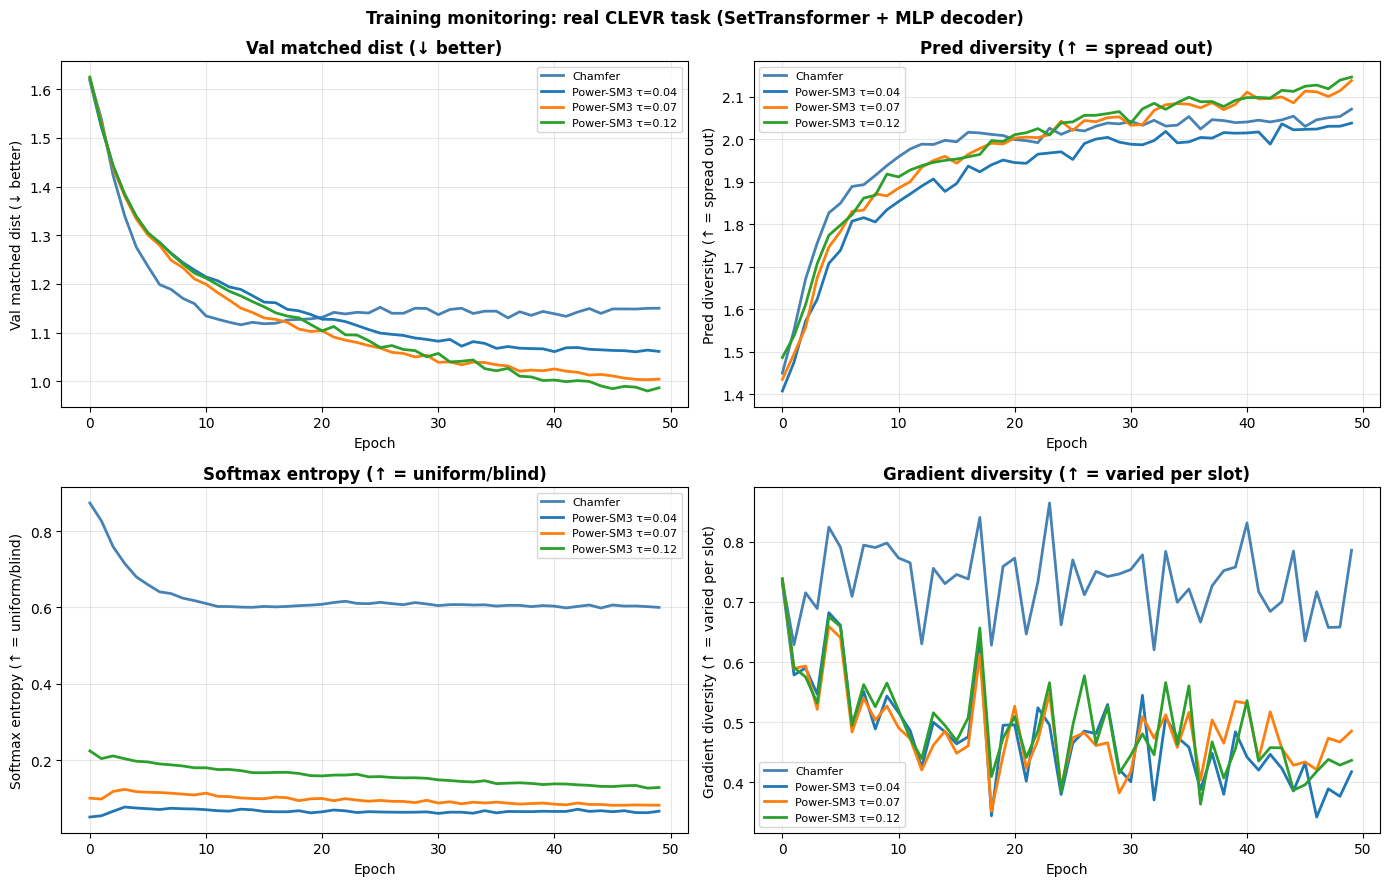

In [30]:
# Handle missing entries gracefully by checking for their presence before plotting
all_results = {}

# Attempt to add Chamfer metrics if available
try:
    all_results['Chamfer'] = (chamfer_metrics, chamfer_snaps)
except NameError:
    pass

# Attempt to add Hungarian metrics if available
try:
    all_results['Hungarian'] = (hungarian_metrics, hungarian_snaps)
except NameError:
    pass

# Attempt to add DSPN metrics if available
try:
    all_results['DSPN'] = (dspn_metrics, dspn_snaps)
except NameError:
    pass

# Attempt to add Power-SM3 entries if available
for tau in tau_list:
    try:
        key = f'Power-SM3 τ={tau}'
        all_results[key] = power_sm_results[tau]
    except (NameError, KeyError):
        pass

colors = {
    'Chamfer':           'steelblue',
    'Hungarian':         'seagreen',
    'DSPN':              'black',
    'Power-SM3 τ=0.05':  'tomato',
    'Power-SM3 τ=0.1':   'darkorange',
    'Power-SM3 τ=0.5':   'mediumorchid',
}

monitor_keys = [
    ('val_matched_dist', 'Val matched dist (↓ better)'),
    ('pred_diversity',   'Pred diversity (↑ = spread out)'),
    ('softmax_entropy',  'Softmax entropy (↑ = uniform/blind)'),
    ('grad_diversity',   'Gradient diversity (↑ = varied per slot)'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, (key, ylabel) in zip(axes, monitor_keys):
    for name, (m, _) in all_results.items():
        # Only plot if the key exists in the metrics
        if key in m:
            try:
                ax.plot(m['epoch'], m[key], label=name, color=colors.get(name, None), lw=2)
            except Exception as err:
                print(f"Problem plotting {name}::{key}: {err}")
        else:
            print(f"Skipping {name} for missing metric: {key}")
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Training monitoring: real CLEVR task (SetTransformer + MLP decoder)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

## 7. PCA Snapshots: Where Are Predictions Through Training?

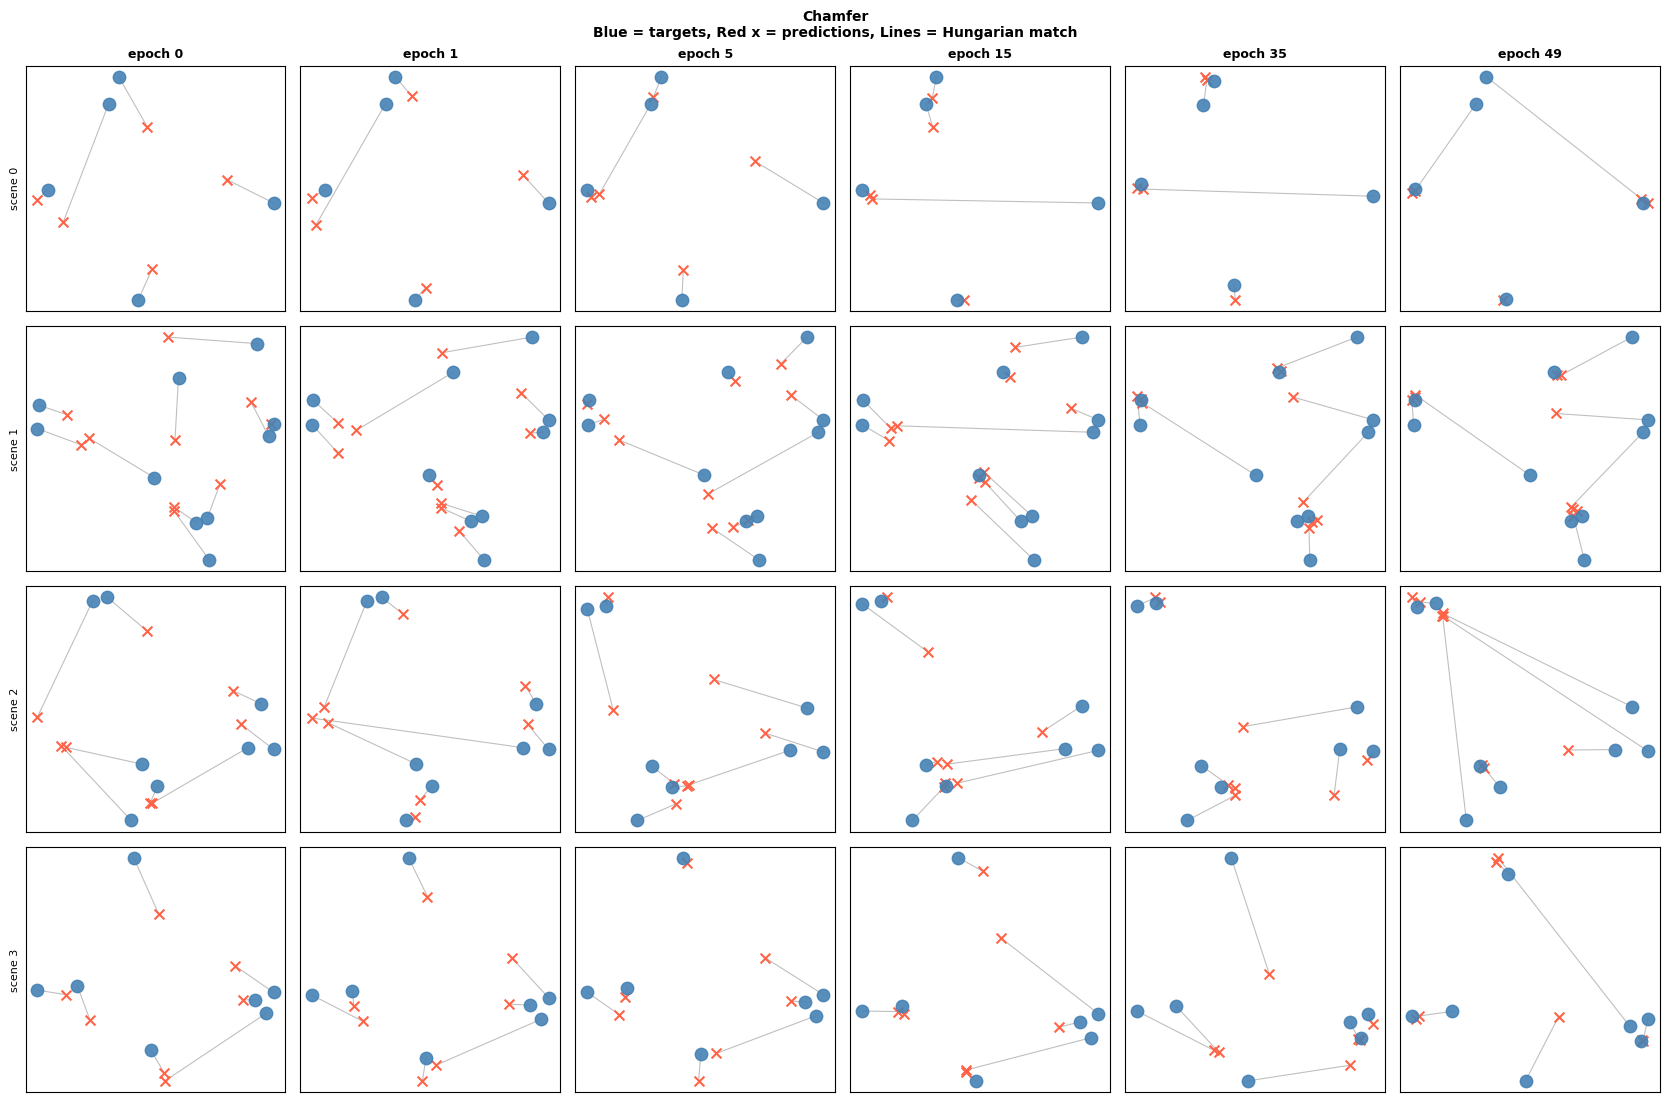

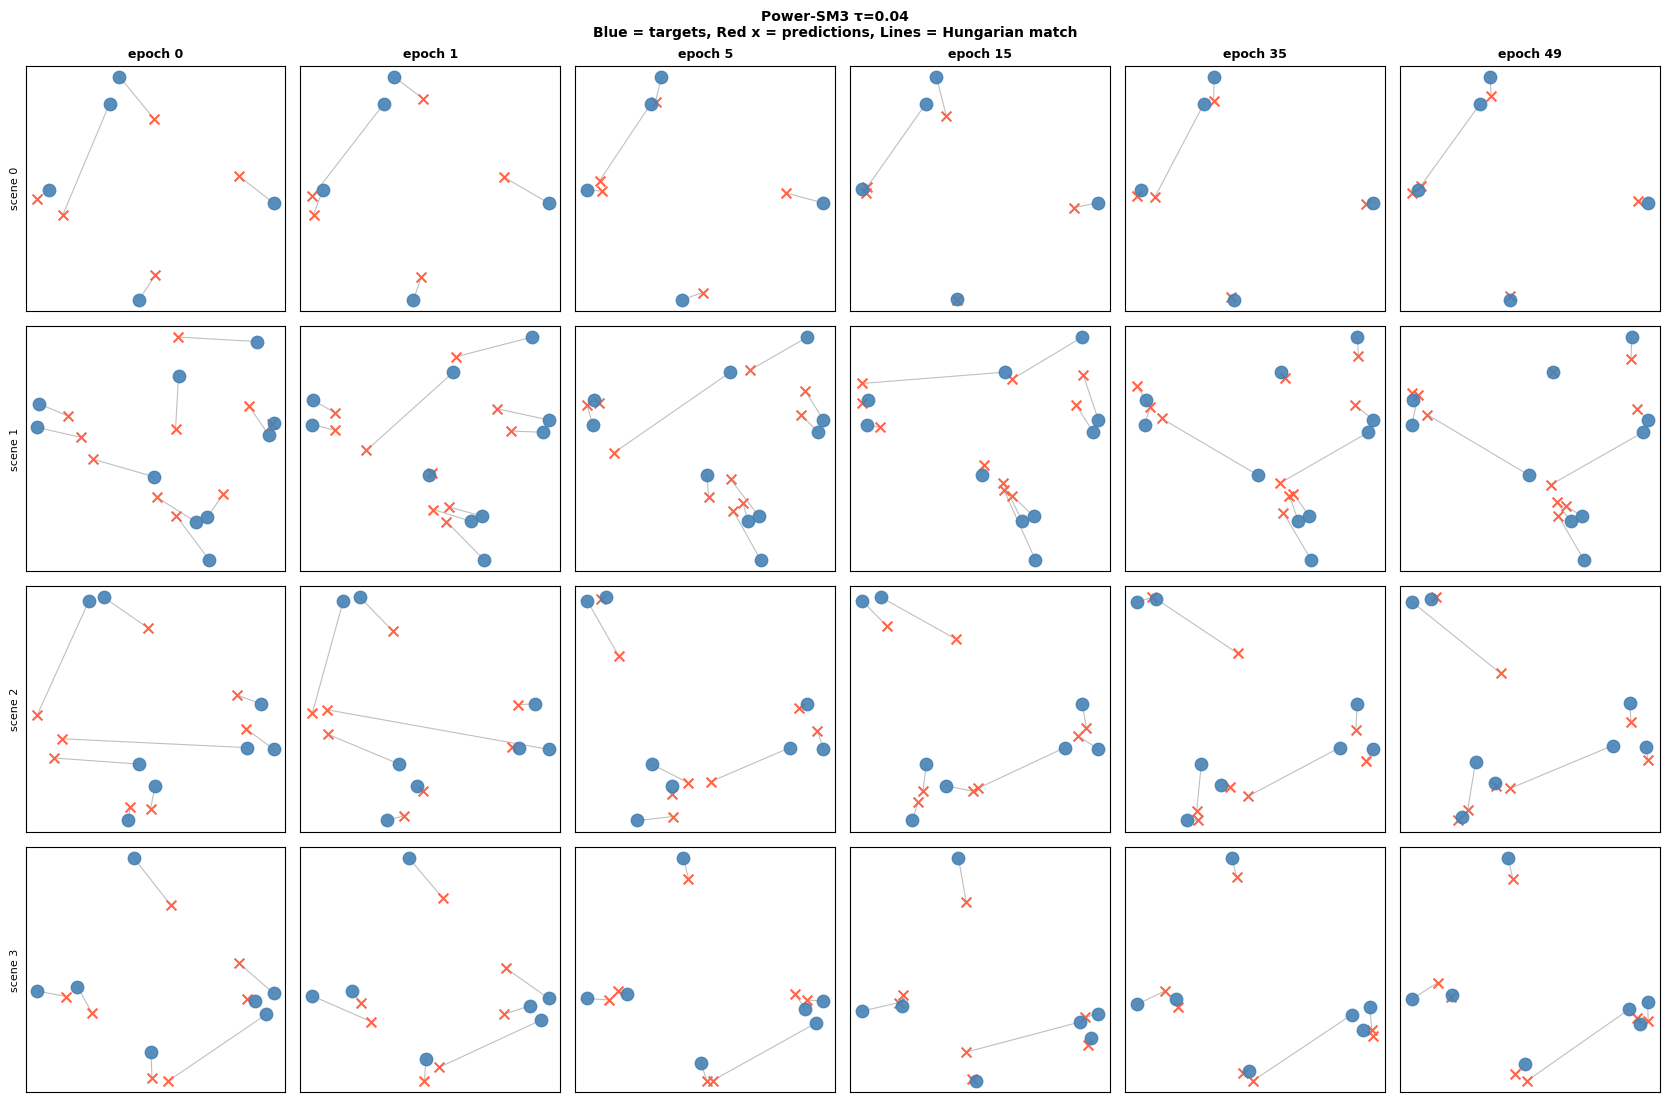

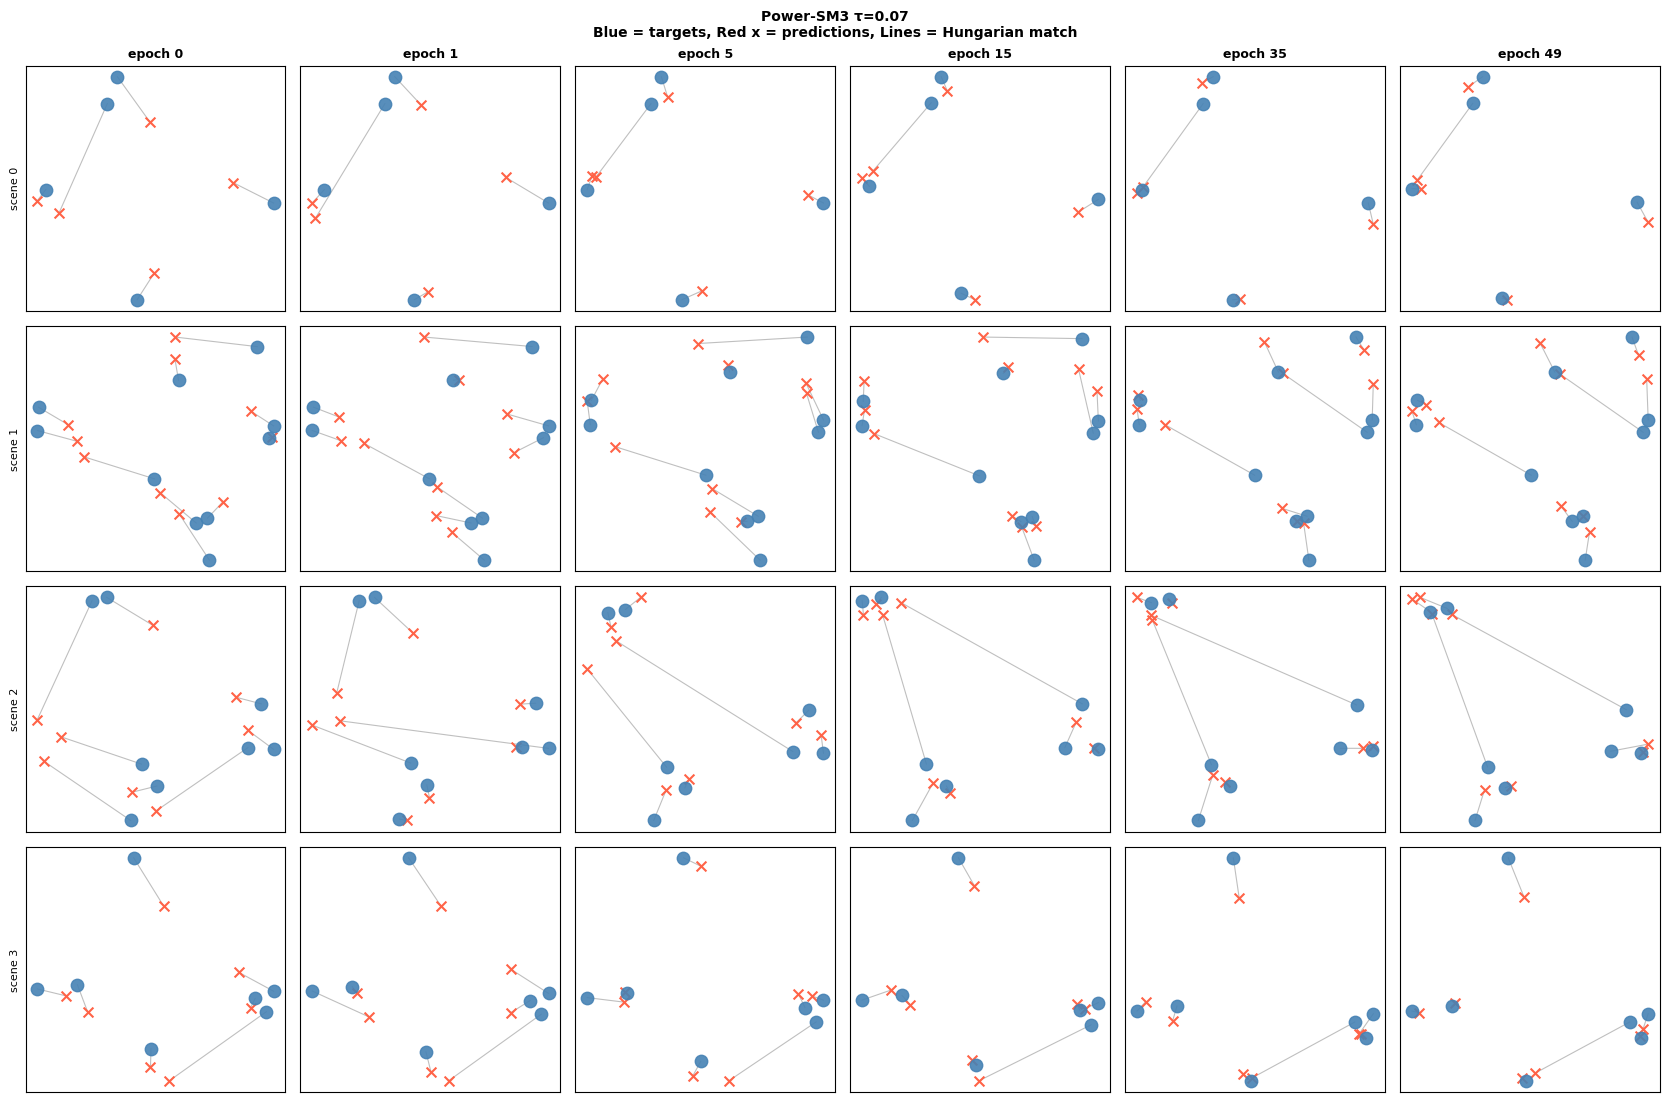

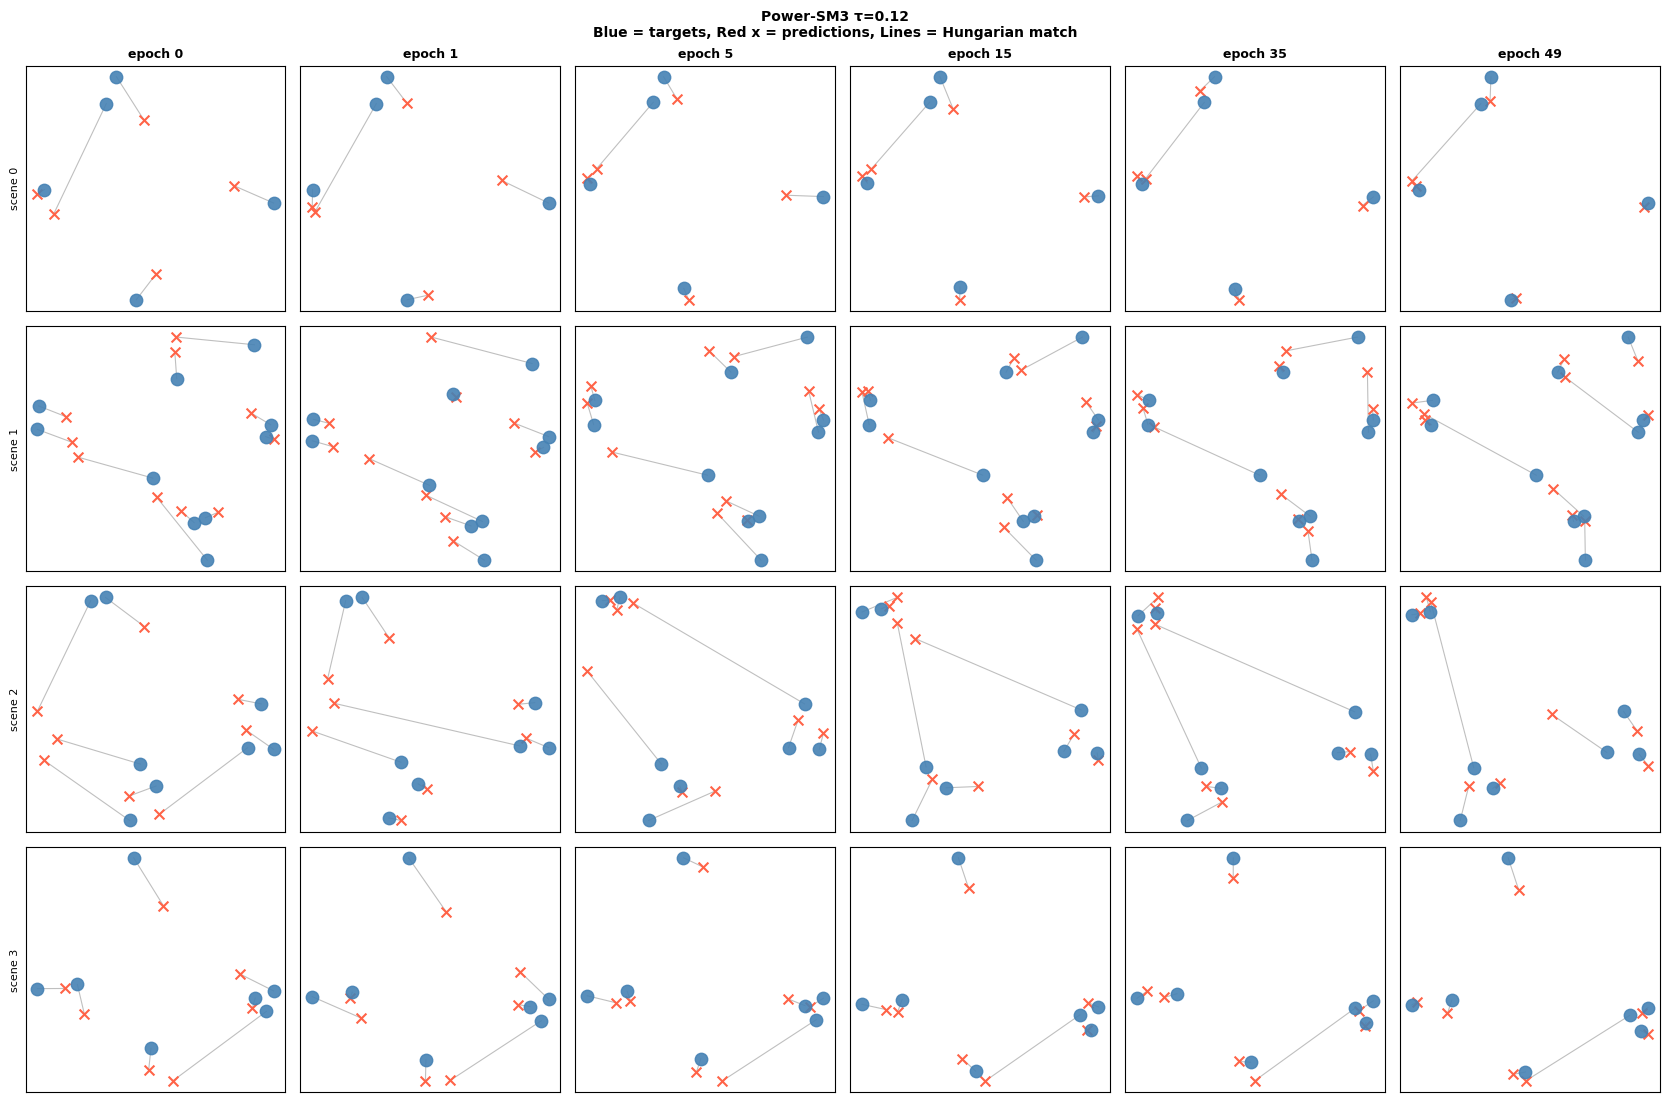

In [31]:
def plot_pca_snapshots(snapshots, title, n_scenes=4):
    """Plot PCA projection of predictions vs targets at each snapshot epoch.

    Fits PCA on all targets from the fixed batch, then projects both
    targets and predictions into the same 2D space.
    """
    n_snaps = len(snapshots)
    fig, axes = plt.subplots(n_scenes, n_snaps,
                              figsize=(n_snaps * 2.8, n_scenes * 2.8))

    # Fit PCA on all real targets across the batch (epoch 0 snapshot)
    _, _, tgt_all, msk_all = snapshots[0]
    real_tgts = np.vstack([
        tgt_all[b, :int(msk_all[b].sum())]
        for b in range(tgt_all.shape[0])
    ])
    pca = PCA(n_components=2)
    pca.fit(real_tgts)

    for col, (epoch, preds_np, tgt_np, msk_np) in enumerate(snapshots):
        for row in range(n_scenes):
            ax = axes[row, col]
            n = int(msk_np[row].sum())

            tgt_2d  = pca.transform(tgt_np[row,  :n])
            pred_2d = pca.transform(preds_np[row, :n])

            ax.scatter(*tgt_2d.T,  s=80, c='steelblue', zorder=5, alpha=0.9)
            ax.scatter(*pred_2d.T, s=50, c='tomato',    zorder=4,
                        marker='x', linewidths=1.5)

            # Draw lines from each pred to its Hungarian match
            D_sub = np.sqrt(((pred_2d[:, None] - tgt_2d[None, :]) ** 2).sum(-1))
            row_idx, col_idx = linear_sum_assignment(D_sub)
            for r, c in zip(row_idx, col_idx):
                ax.plot([pred_2d[r, 0], tgt_2d[c, 0]],
                        [pred_2d[r, 1], tgt_2d[c, 1]],
                        c='gray', lw=0.8, alpha=0.5, zorder=3)

            if row == 0:
                ax.set_title(f'epoch {epoch}', fontweight='bold', fontsize=9)
            if col == 0:
                ax.set_ylabel(f'scene {row}', fontsize=8)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.grid(alpha=0.2)

    plt.suptitle(f'{title}\nBlue = targets, Red x = predictions, Lines = Hungarian match',
                 fontweight='bold', fontsize=10)
    plt.tight_layout()
    plt.show()


for name, (_, snaps) in all_results.items():
    plot_pca_snapshots(snaps, title=name, n_scenes=4)

## 8. Per-Slot Gradient Norms: Are All Slots Getting Identical Signals?

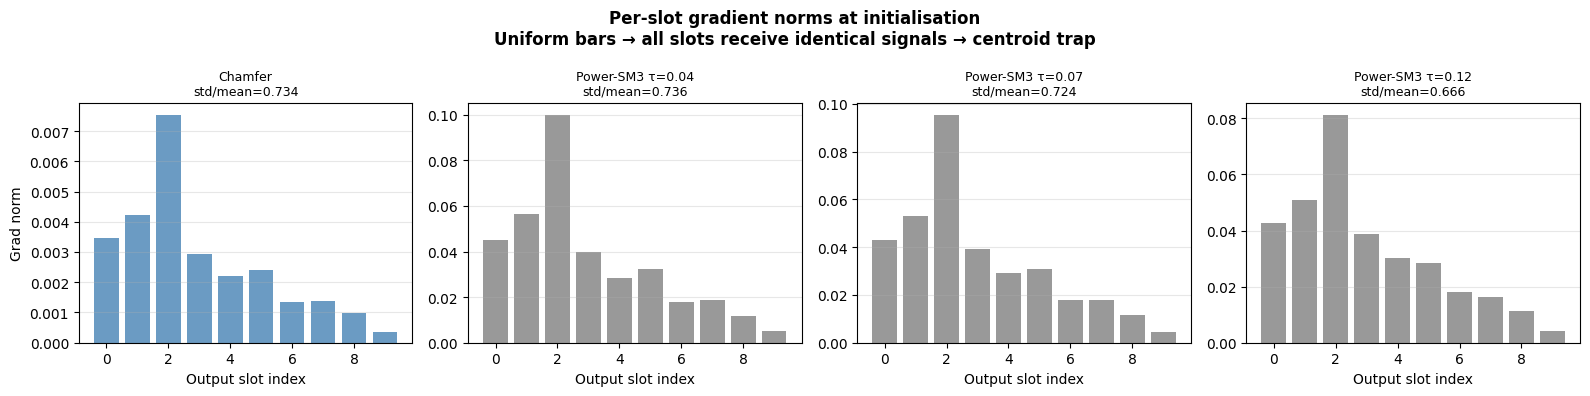

In [32]:
def slot_grad_norms(model, batch, loss_fn):
    """Return (M,) array of mean per-slot gradient norms over the batch."""
    inp, tgt, msk = [x.to(DEVICE) for x in batch]
    slot_grads = {}
    def hook(grad):
        slot_grads['g'] = grad.detach().cpu()

    model.train()
    preds = model(inp, mask=msk)
    preds.register_hook(hook)
    D = torch.cdist(preds, tgt)
    loss_fn(D, mask=msk).backward()
    model.zero_grad()

    g = slot_grads['g']  # (B, M, D)
    return g.norm(dim=2).mean(dim=0).numpy()  # (M,)


# Rebuild models at epoch 0 (fresh init) and compare slot grad norms
probe_batch = next(iter(train_loader))

fig, axes = plt.subplots(1, len(all_results), figsize=(16, 4), sharey=False)

for ax, (name, (m, snaps)) in zip(axes, all_results.items()):
    # We need a fresh model to probe at init — rebuild with same seed
    torch.manual_seed(42)
    probe_model = make_model()

    # Use the right loss
    if 'Chamfer' in name:
        probe_fn = ChamferLoss()
    else:
        tau = float(name.split('τ=')[1])
        probe_fn = PowerSoftMinLoss(temperature=tau, power=3.0)

    norms = slot_grad_norms(probe_model, probe_batch, probe_fn)
    ax.bar(range(MAX_OBJECTS), norms, color=colors.get(name, 'gray'), alpha=0.8)
    ax.set_title(f'{name}\nstd/mean={norms.std()/norms.mean():.3f}', fontsize=9)
    ax.set_xlabel('Output slot index')
    if ax == axes[0]:
        ax.set_ylabel('Grad norm')
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Per-slot gradient norms at initialisation\n'
             'Uniform bars → all slots receive identical signals → centroid trap',
             fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Summary Table

In [33]:
print(f"{'Loss':<22} {'Final dist':>12} {'Pred div':>10} {'SM entropy':>12} {'Grad div':>10}")
print('-' * 70)
for name, (m, _) in all_results.items():
    print(f"{name:<22} "
          f"{m['val_matched_dist'][-1]:>12.4f} "
          f"{m['pred_diversity'][-1]:>10.4f} "
          f"{m['softmax_entropy'][-1]:>12.4f} "
          f"{m['grad_diversity'][-1]:>10.4f}")

Loss                     Final dist   Pred div   SM entropy   Grad div
----------------------------------------------------------------------
Chamfer                      1.1500     2.0715       0.6001     0.7860
Power-SM3 τ=0.04             1.0612     2.0384       0.0662     0.4175
Power-SM3 τ=0.07             1.0043     2.1387       0.0818     0.4852
Power-SM3 τ=0.12             0.9865     2.1469       0.1283     0.4365
